# Phoenix Surrogate vs. Agama Torus Mapping
This notebook validates the trained Phoenix Neural Network by comparing its phase-space predictions directly against Agama's exact analytic torus mapping for the exact same actions, angles, and potential parameters.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import agama
import time
import sys
import os

# Import our trained mapper from the inference script
# (Ensure inference_phoenix.py is in the same directory as this notebook)
from phoenix.actions_to_phasespace.actions_to_phasespace_nn import PhoenixMapper

In [3]:
# 1. Initialize Phoenix Mapper
# It will automatically find the weights and stats files based on the setup in inference_phoenix.py
mapper = PhoenixMapper()

# 2. Initialize Agama Units
agama.setUnits(mass=1, length=1, velocity=1)

Loading Phoenix Surrogate Model...
 -> Weights: /home/annalena/phoenix/phoenix/torus_mapping_neural_network/phoenix_weights.msgpack
 -> Stats:   /home/annalena/phoenix/phoenix/torus_mapping_neural_network/phoenix_norm_stats.npz
Model loaded and ready for inference!


In [4]:
### DEFINE THE GALACTIC POTENTIAL ###

# Physical Parameters for a Milky Way-like Galaxy
halo_mass_true = 1e12
halo_scale = 20.0
disk_mass_true = 5e10
disk_scale = 3.0
disk_height = 0.3
bulge_mass_true = 1e10
bulge_scale = 1.0

# --- Setup Agama Potential ---
disk_sigma = disk_mass_true / (2 * np.pi * disk_scale**2)
halo = agama.Potential(type='NFW', mass=halo_mass_true, scaleRadius=halo_scale)
disk = agama.Potential(type='Disk', surfaceDensity=disk_sigma, scaleRadius=disk_scale, scaleHeight=disk_height)
bulge = agama.Potential(type='Spheroid', mass=bulge_mass_true, scaleRadius=bulge_scale, gamma=1, beta=4, alpha=1)
total_potential = agama.Potential(halo, disk, bulge)

agama_mapper = agama.ActionMapper(total_potential)

# --- Setup Neural Network Potential Input ---
# CRITICAL: Scale masses down by 1e11 to match how the training data was engineered!
nn_potential_params = np.array([
    halo_mass_true / 1e11, halo_scale,
    disk_mass_true / 1e11, disk_scale, disk_height,
    bulge_mass_true / 1e11, bulge_scale
])

In [5]:
### GENERATE TEST ACTIONS AND ANGLES ###
np.random.seed(123)
N_samples = 5000

# Sample Actions (J_R, J_z, J_phi)
J_R = np.random.uniform(5.0, 150.0, N_samples)
J_z = np.random.uniform(2.0, 80.0, N_samples)
J_phi = np.random.uniform(100.0, 3000.0, N_samples)
test_actions = np.vstack([J_R, J_z, J_phi]).T

# Sample Angles
test_angles = np.random.uniform(0, 2 * np.pi, (N_samples, 3))

# Format for Agama (N, 6)
action_angles_agama = np.hstack([test_actions, test_angles])

# Format for Phoenix (Tile the 1D potential array N times for the batch)
test_potentials = np.tile(nn_potential_params, (N_samples, 1))

In [6]:
### EXECUTE MAPPINGS & COMPARE TIMING ###

# 1. Agama Timing & Execution
t0 = time.time()
agama_phase_space = agama_mapper(action_angles_agama)
agama_time = time.time() - t0
print(f"Agama Processing Time: {agama_time:.4f} seconds")

# 2. Phoenix NN Timing & Execution
t1 = time.time()
nn_phase_space = mapper.map_to_phase_space(test_actions, test_angles, test_potentials)
nn_time = time.time() - t1
print(f"Phoenix NN Processing Time: {nn_time:.4f} seconds")

speedup = agama_time / nn_time
print(f"\nPhoenix is {speedup:.1f}x faster!")

Agama Processing Time: 78.2059 seconds
Phoenix NN Processing Time: 0.6011 seconds

Phoenix is 130.1x faster!


Mean Position Error: nan kpc
Mean Velocity Error: nan km/s


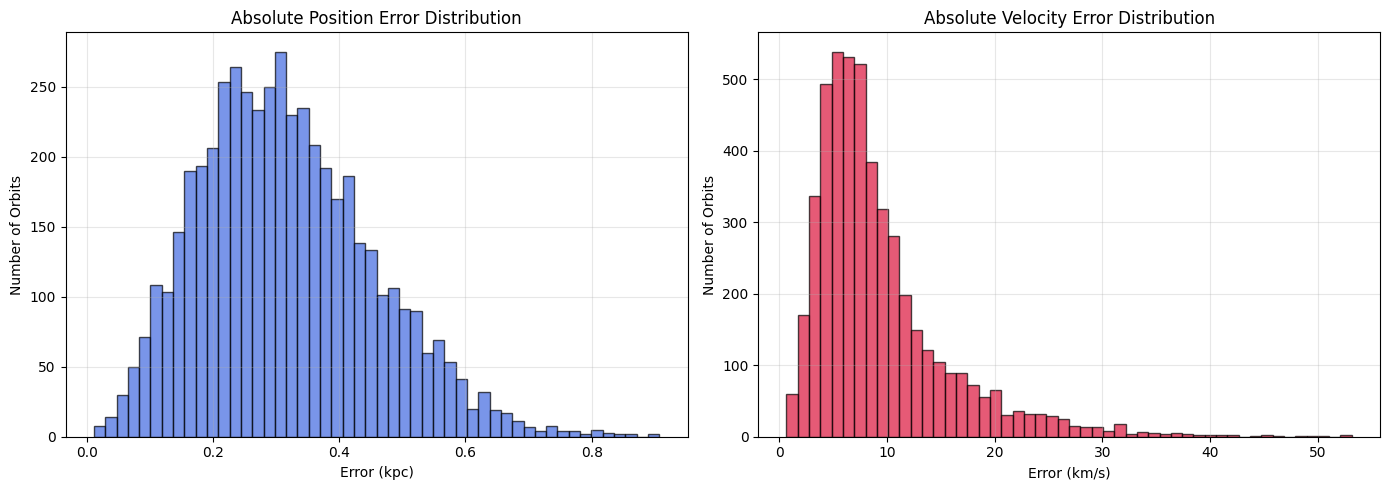

In [7]:
### CALCULATE & PLOT ABSOLUTE ERRORS ###
pos_error = np.linalg.norm(nn_phase_space[:, 0:3] - agama_phase_space[:, 0:3], axis=1)
vel_error = np.linalg.norm(nn_phase_space[:, 3:6] - agama_phase_space[:, 3:6], axis=1)

print(f"Mean Position Error: {np.mean(pos_error):.4f} kpc")
print(f"Mean Velocity Error: {np.mean(vel_error):.4f} km/s")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(pos_error, bins=50, color='royalblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Absolute Position Error Distribution')
axes[0].set_xlabel('Error (kpc)')
axes[0].set_ylabel('Number of Orbits')
axes[0].grid(alpha=0.3)

axes[1].hist(vel_error, bins=50, color='crimson', edgecolor='black', alpha=0.7)
axes[1].set_title('Absolute Velocity Error Distribution')
axes[1].set_xlabel('Error (km/s)')
axes[1].set_ylabel('Number of Orbits')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

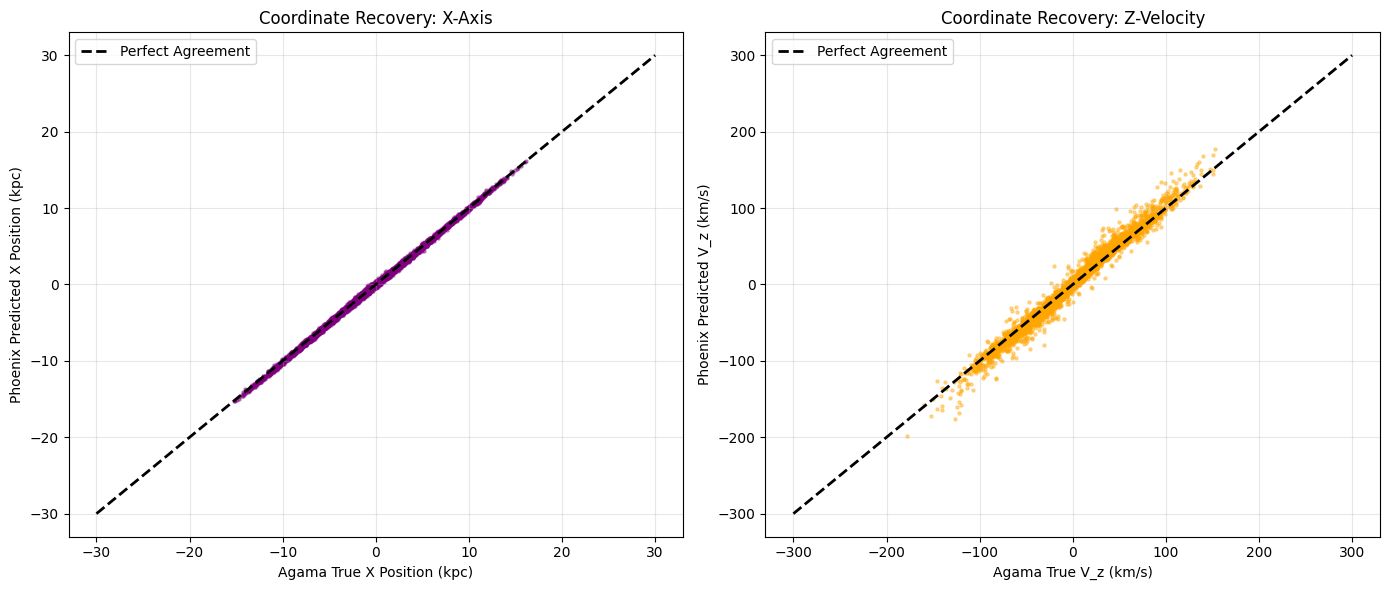

In [8]:
### VISUALIZE TRUE VS PREDICTED COORDINATES ###
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot X Position (Agama vs NN)
axes[0].scatter(agama_phase_space[:, 0], nn_phase_space[:, 0], alpha=0.4, s=5, c='purple')
axes[0].plot([-30, 30], [-30, 30], 'k--', lw=2, label='Perfect Agreement')
axes[0].set_xlabel('Agama True X Position (kpc)')
axes[0].set_ylabel('Phoenix Predicted X Position (kpc)')
axes[0].set_title('Coordinate Recovery: X-Axis')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot V_Z Velocity (Agama vs NN)
axes[1].scatter(agama_phase_space[:, 5], nn_phase_space[:, 5], alpha=0.4, s=5, c='orange')
axes[1].plot([-300, 300], [-300, 300], 'k--', lw=2, label='Perfect Agreement')
axes[1].set_xlabel('Agama True V_z (km/s)')
axes[1].set_ylabel('Phoenix Predicted V_z (km/s)')
axes[1].set_title('Coordinate Recovery: Z-Velocity')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Generating Coordinate Recovery Scatter Plots...


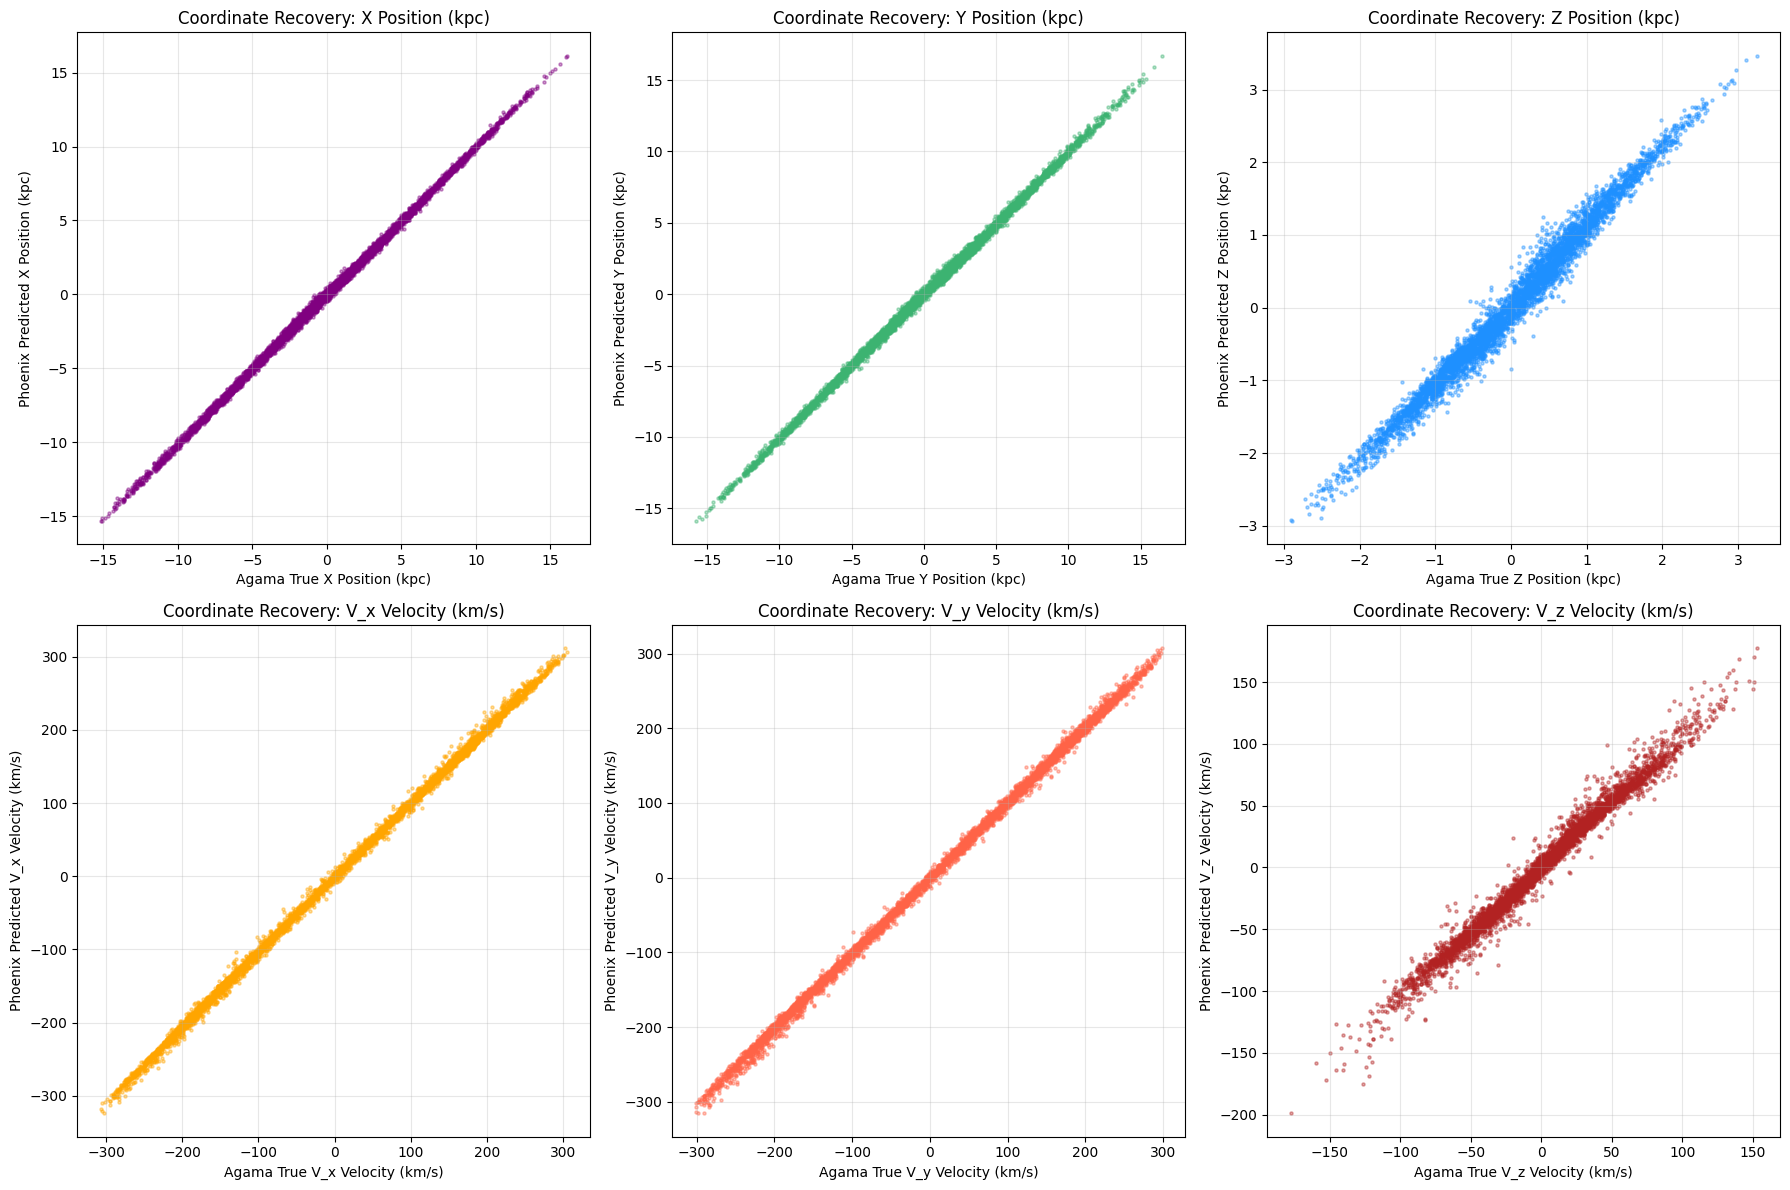

In [9]:
print("Generating Coordinate Recovery Scatter Plots...")
fig2, axes2 = plt.subplots(2, 3, figsize=(18, 12))
axes2 = axes2.flatten()

labels = ['X Position (kpc)', 'Y Position (kpc)', 'Z Position (kpc)', 
            'V_x Velocity (km/s)', 'V_y Velocity (km/s)', 'V_z Velocity (km/s)']
colors = ['purple', 'mediumseagreen', 'dodgerblue', 'orange', 'tomato', 'firebrick']

for i in range(6):
    ax = axes2[i]
    true_val = agama_phase_space[:, i]
    pred_val = nn_phase_space[:, i]
    
    ax.scatter(true_val, pred_val, alpha=0.4, s=5, c=colors[i])
    
    # Dynamic diagonal line based on data limits
    min_val = min(true_val.min(), pred_val.min())
    max_val = max(true_val.max(), pred_val.max())
    
    # Add a 5% buffer to the limits so points aren't cut off
    buf = (max_val - min_val) * 0.05
    #ax.plot([min_val - buf, max_val + buf], [min_val - buf, max_val + buf], 'k--', lw=2, label='Perfect Agreement')
    
    ax.set_xlabel(f'Agama True {labels[i]}')
    ax.set_ylabel(f'Phoenix Predicted {labels[i]}')
    ax.set_title(f'Coordinate Recovery: {labels[i]}')
    #ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()